##Nueva Prueba de Ingenieria de Caracteristicas

In [1]:
# [CELDA DEPENDENCIAS]
!pip install -q shap xgboost lightgbm
print("✅ Librerías instaladas.")

✅ Librerías instaladas.


In [2]:
# [CELDA 1] CARGA MASIVA Y PREPARACIÓN DEL DATASET
import kagglehub
import pandas as pd
import numpy as np
import os, glob, random, gc, json
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.linear_model import LogisticRegression

# ==========================================
# 0. FIJAR SEMILLAS PARA REPRODUCIBILIDAD EXACTA
# ==========================================
def fijar_semillas(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

fijar_semillas(42)

print("=== FASE 0: EXTRACCIÓN MASIVA Y COMPRESIÓN (Entorno 1:1) ===")

path = kagglehub.dataset_download("mkashifn/nbaiot-dataset")
all_csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)

benign_list, bashlite_list, mirai_list = [], [], []
MUESTRAS_POR_ARCHIVO = 100000

print(f"Cargando hasta {MUESTRAS_POR_ARCHIVO} registros por archivo (Float32)...")
for file in all_csv_files:
    try:
        total_rows = sum(1 for _ in open(file, 'r')) - 1
        if total_rows > 0:
            np.random.seed(42)
            skip = sorted(np.random.choice(range(1, total_rows + 1), max(0, total_rows - MUESTRAS_POR_ARCHIVO), replace=False))
            df = pd.read_csv(file, skiprows=skip).dropna()

            for col in df.columns:
                if df[col].dtype == 'float64': df[col] = df[col].astype('float32')

            if "benign" in file.lower():
                df['label'] = 0
                benign_list.append(df)
            elif "gafgyt" in file.lower() or "bashlite" in file.lower():
                df['label'] = 1
                bashlite_list.append(df)
            elif "mirai" in file.lower():
                df['label'] = 2
                mirai_list.append(df)
    except: pass

DF_BENIGN = pd.concat(benign_list, ignore_index=True)
DF_BASHLITE = pd.concat(bashlite_list, ignore_index=True)
DF_MIRAI = pd.concat(mirai_list, ignore_index=True)

MIN_SAMPLES = min(len(DF_BENIGN), len(DF_BASHLITE), len(DF_MIRAI))
print(f"\nBalanceando a {MIN_SAMPLES} muestras por clase...")

DF_GLOBAL = pd.concat([
    DF_BENIGN.sample(n=MIN_SAMPLES, random_state=42),
    DF_BASHLITE.sample(n=MIN_SAMPLES, random_state=42),
    DF_MIRAI.sample(n=MIN_SAMPLES, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

X_raw = DF_GLOBAL.drop(columns=['label'])
y_global = DF_GLOBAL['label']

print("Aplicando Filtro de Varianza y RobustScaler global...")
selector = VarianceThreshold(threshold=0.0)
X_var = X_raw[X_raw.columns[selector.fit(X_raw).get_support()]]
X_scaled = pd.DataFrame(RobustScaler().fit_transform(X_var), columns=X_var.columns)

print(f"Dataset listo: {X_scaled.shape[0]} filas, {X_scaled.shape[1]} características.")

# LIMPIEZA DE RAM PARA LA CELDA 1
del DF_BENIGN, DF_BASHLITE, DF_MIRAI, DF_GLOBAL, X_raw, X_var, benign_list, bashlite_list, mirai_list
gc.collect()
print("🗑️ RAM liberada. Listo para los pipelines.")

=== FASE 0: EXTRACCIÓN MASIVA Y COMPRESIÓN (Entorno 1:1) ===


100%|██████████| 1.75G/1.75G [00:21<00:00, 89.1MB/s]

Extracting files...


Cargando hasta 100000 registros por archivo (Float32)...


/tmp/ipykernel_4134/3014926375.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['label'] = 2
/tmp/ipykernel_4134/3014926375.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['label'] = 0
/tmp/ipykernel_4134/3014926375.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['label'] = 2
/


Balanceando a 480692 muestras por clase...
Aplicando Filtro de Varianza y RobustScaler global...
Dataset listo: 1442076 filas, 115 características.
🗑️ RAM liberada. Listo para los pipelines.


In [3]:
# [CELDA 2] INSTALACIÓN DE DEPENDENCIAS Y MUESTRA
!pip install -q xgboost lightgbm catboost shap
import pandas as pd
import numpy as np
import os, random, json, gc, time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

print("=== FASE 0.5: PREPARACIÓN DE MUESTRA PARA 15 ALGORITMOS ===")

# Tomamos una muestra balanceada de 100,000 registros para velocidad
X_fast, _, y_fast, _ = train_test_split(
    X_scaled, y_global, train_size=100000, random_state=42, stratify=y_global
)

# Submuestra de 80k para algoritmos matemáticamente pesados (SHAP, RFE, MI)
X_heavy_sample = X_fast.sample(n=80000, random_state=42)
y_heavy_sample = y_fast.sample(n=80000, random_state=42)

print(f"Dataset Principal listo: {X_fast.shape[0]} filas | {X_fast.shape[1]} variables.")
print(f"Submuestra Pesada lista: {X_heavy_sample.shape[0]} filas.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 12.9 MB/s eta 0:00:00
=== FASE 0.5: PREPARACIÓN DE MUESTRA PARA 15 ALGORITMOS ===
Dataset Principal listo: 100000 filas | 115 variables.
Submuestra Pesada lista: 80000 filas.


In [ ]:
# [CELDA 3] FASE 1: EVALUACIÓN NATURAL (LOS 15 TITANES)
from sklearn.feature_selection import mutual_info_classif, f_classif, RFECV
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import shap

print("=== FASE 1: EVALUACIÓN NATURAL (15 ALGORITMOS) ===")
inicio_total = time.time()
archivos_generados = {}

def guardar_ranking(nombre_archivo, variables):
    with open(nombre_archivo, 'w') as f: json.dump(variables, f)
    archivos_generados[nombre_archivo.replace('.json', '')] = nombre_archivo
    print(f"   -> Conservó: {len(variables)} variables. Guardado en '{nombre_archivo}'")

# 1. Spearman
print("\n[1/15] Spearman...")
familias = {}
for col in X_fast.columns:
    fam = col.replace('_L5_', '_').replace('_L3_', '_').replace('_L1_', '_').replace('_L0.1_', '_').replace('_L0.01_', '_')
    if fam not in familias: familias[fam] = []
    familias[fam].append(col)
a_eliminar = []
for fam, cols in familias.items():
    if len(cols) > 1:
        corr = X_fast[cols].corr(method='spearman').abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        for c in upper.columns:
            if any(upper[c] > 0.99): a_eliminar.append(c)
guardar_ranking('01_spearman.json', [c for c in X_fast.columns if c not in a_eliminar])

# 2. Mutual Information
print("\n[2/15] Mutual Information...")
mi_scores = mutual_info_classif(X_heavy_sample, y_heavy_sample, random_state=42)
guardar_ranking('02_mutualinfo.json', X_fast.columns[mi_scores > np.mean(mi_scores)].tolist())

# 3. ANOVA
print("\n[3/15] ANOVA f-score...")
f_scores, _ = f_classif(X_fast.astype('float64'), y_fast)
guardar_ranking('03_anova.json', X_fast.columns[np.nan_to_num(f_scores, nan=0.0) > np.mean(np.nan_to_num(f_scores, nan=0.0))].tolist())

# 4. Random Forest
print("\n[4/15] Random Forest...")
rf = RandomForestClassifier(n_estimators=40, max_depth=12, random_state=42, n_jobs=-1).fit(X_fast, y_fast)
guardar_ranking('04_randomforest.json', X_fast.columns[rf.feature_importances_ > np.mean(rf.feature_importances_)].tolist())

# 5. LightGBM
print("\n[5/15] LightGBM...")
lgb_clf = lgb.LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1).fit(X_fast, y_fast)
imp_lgb = lgb_clf.booster_.feature_importance(importance_type='gain')
guardar_ranking('05_lightgbm.json', X_fast.columns[imp_lgb > np.mean(imp_lgb)].tolist())

# 6. XGBoost
print("\n[6/15] XGBoost...")
xgb_clf = xgb.XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1).fit(X_fast, y_fast)
imp_xgb = np.array([xgb_clf.get_booster().get_score(importance_type='gain').get(c, 0.0) for c in X_fast.columns])
guardar_ranking('06_xgboost.json', X_fast.columns[imp_xgb > np.mean(imp_xgb)].tolist())

# 7. CatBoost
print("\n[7/15] CatBoost...")
cb_clf = CatBoostClassifier(iterations=100, depth=8, random_state=42, verbose=0, thread_count=-1).fit(X_fast, y_fast)
guardar_ranking('07_catboost.json', X_fast.columns[cb_clf.feature_importances_ > np.mean(cb_clf.feature_importances_)].tolist())

# 8. Lasso L1
print("\n[8/15] Lasso L1...")
lasso = LogisticRegression(penalty='l1', solver='saga', max_iter=150, random_state=42, n_jobs=-1).fit(X_fast, y_fast)
guardar_ranking('08_lasso.json', X_fast.columns[np.sum(np.abs(lasso.coef_), axis=0) > 0.001].tolist())

# 9. Ridge L2
print("\n[9/15] Regresión Ridge L2...")
ridge = LogisticRegression(penalty='l2', solver='saga', max_iter=150, random_state=42, n_jobs=-1).fit(X_fast, y_fast)
pesos_l2 = np.sum(np.abs(ridge.coef_), axis=0)
guardar_ranking('09_ridge_l2.json', X_fast.columns[pesos_l2 > np.mean(pesos_l2)].tolist())

# 10. ElasticNet
print("\n[10/15] ElasticNet L1+L2...")
elastic = LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, C=1.0, max_iter=150, random_state=42, n_jobs=-1).fit(X_fast, y_fast)
pesos_en = np.sum(np.abs(elastic.coef_), axis=0)
guardar_ranking('10_elasticnet.json', X_fast.columns[pesos_en > 0.001].tolist())

# 11. Extra Trees
print("\n[11/15] Extra Trees...")
xt = ExtraTreesClassifier(n_estimators=40, max_depth=12, random_state=42, n_jobs=-1).fit(X_fast, y_fast)
guardar_ranking('11_extratrees.json', X_fast.columns[xt.feature_importances_ > np.mean(xt.feature_importances_)].tolist())

# 12. PFI
print("\n[12/15] Permutation Importance PFI...")
dt_base = DecisionTreeClassifier(max_depth=12, random_state=42).fit(X_fast, y_fast)
res_pfi = permutation_importance(dt_base, X_heavy_sample, y_heavy_sample, n_repeats=3, random_state=42, n_jobs=-1)
guardar_ranking('12_pfi.json', X_fast.columns[res_pfi.importances_mean > np.mean(res_pfi.importances_mean)].tolist())

# 13. SHAP
print("\n[13/15] SHAP (Teoría de Juegos)...")
rf_shap = RandomForestClassifier(n_estimators=30, max_depth=10, random_state=42, n_jobs=-1).fit(X_heavy_sample, y_heavy_sample)
shap_vals = shap.TreeExplainer(rf_shap).shap_values(X_heavy_sample.sample(n=5000, random_state=42))
imp_shap = np.mean([np.mean(np.abs(sv), axis=0) for sv in shap_vals], axis=0) if isinstance(shap_vals, list) else np.mean(np.abs(shap_vals), axis=(0, 2) if len(shap_vals.shape)==3 else 0)
guardar_ranking('13_shap.json', X_fast.columns[imp_shap > np.mean(imp_shap)].tolist())

# 14. RFECV Puro
print("\n[14/15] RFECV Wrapper Puro...")
selector_rfe_puro = RFECV(estimator=DecisionTreeClassifier(max_depth=8, random_state=42), step=5, cv=3, scoring='f1_macro', n_jobs=-1).fit(X_heavy_sample, y_heavy_sample)
guardar_ranking('14_rfecv.json', X_fast.columns[selector_rfe_puro.get_support()].tolist())

# 15. RFE-PFI
print("\n[15/15] RFE-PFI Híbrido...")
# Usamos el resultado de RFECV para el PFI
rfe_survivors = X_fast.columns[selector_rfe_puro.get_support()].tolist()
dt_pfi_2 = DecisionTreeClassifier(max_depth=8, random_state=42).fit(X_heavy_sample[rfe_survivors], y_heavy_sample)
res_pfi_2 = permutation_importance(dt_pfi_2, X_heavy_sample[rfe_survivors], y_heavy_sample, n_repeats=3, random_state=42, n_jobs=-1)
guardar_ranking('15_rfe_pfi.json', np.array(rfe_survivors)[res_pfi_2.importances_mean > 0.001].tolist())

print(f"\n✅ FASE 1 COMPLETADA en {round((time.time() - inicio_total)/60, 2)} minutos.")

=== FASE 1: EVALUACIÓN NATURAL (15 ALGORITMOS) ===

[1/15] Spearman...
   -> Conservó: 94 variables. Guardado en '01_spearman.json'

[2/15] Mutual Information...


KeyboardInterrupt: 

=== GENERANDO GRÁFICA RESUMEN DE LA FASE 1 ===


/tmp/ipykernel_4134/3189037876.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


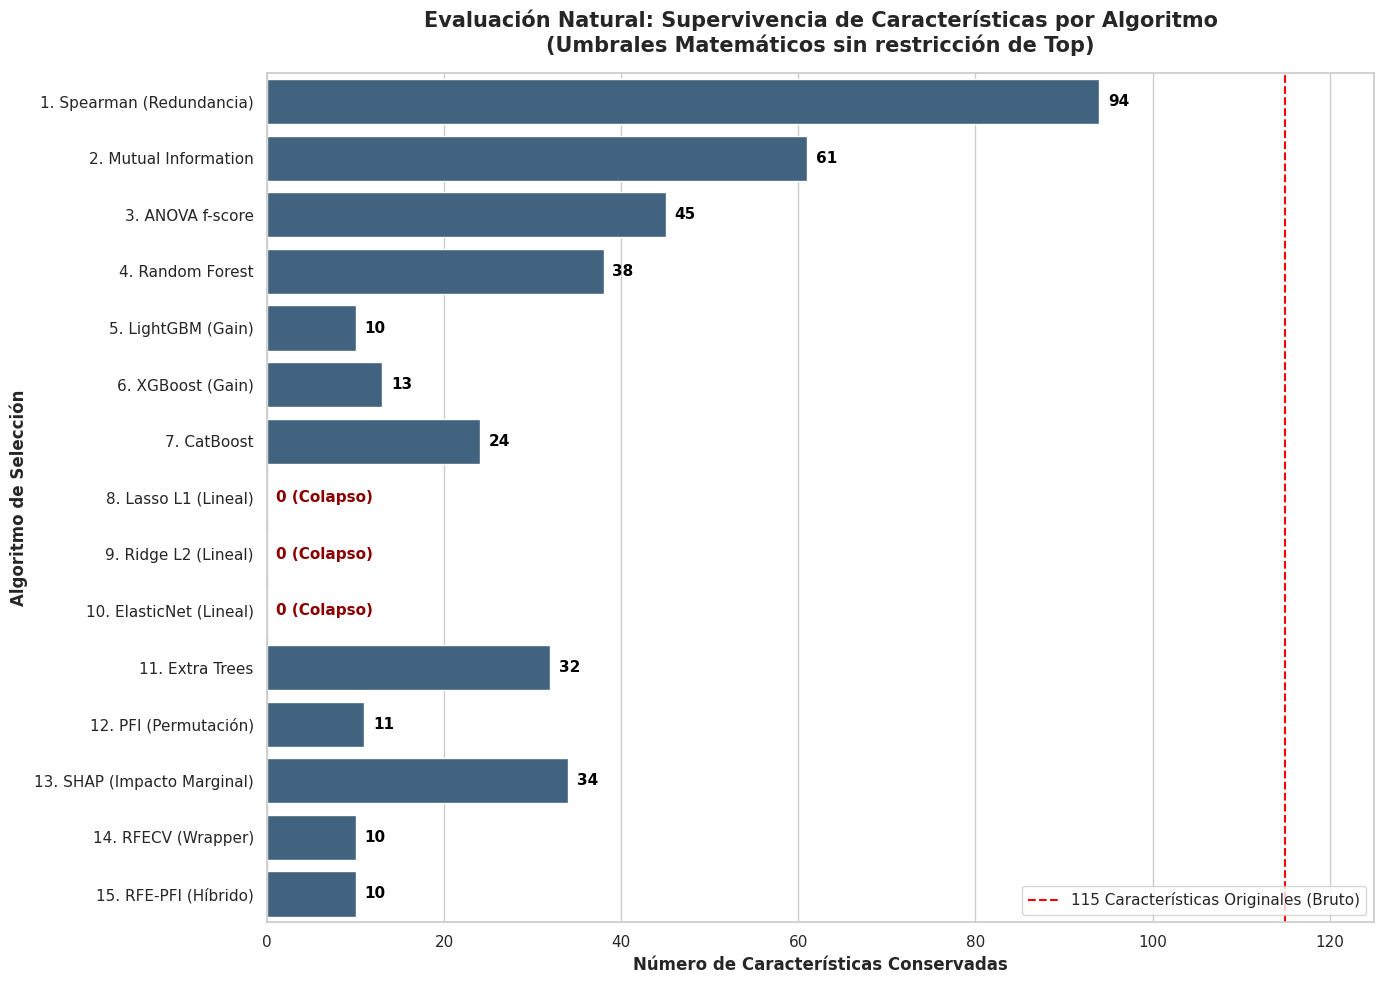

In [4]:
# [CELDA] VISUALIZACIÓN GLOBAL DE LA FASE 1
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("=== GENERANDO GRÁFICA RESUMEN DE LA FASE 1 ===")

# Diccionario con los archivos exactos que generaste y sus nombres legibles
mapa_archivos = {
    '01_spearman.json': '1. Spearman (Redundancia)',
    '02_mutualinfo.json': '2. Mutual Information',
    '03_anova.json': '3. ANOVA f-score',
    '04_randomforest.json': '4. Random Forest',
    '05_lightgbm.json': '5. LightGBM (Gain)',
    '06_xgboost.json': '6. XGBoost (Gain)',
    '07_catboost.json': '7. CatBoost',
    '08_lasso.json': '8. Lasso L1 (Lineal)',
    '09_ridge_l2.json': '9. Ridge L2 (Lineal)',
    '10_elasticnet.json': '10. ElasticNet (Lineal)',
    '11_extratrees.json': '11. Extra Trees',
    '12_pfi.json': '12. PFI (Permutación)',
    '13_shap.json': '13. SHAP (Impacto Marginal)',
    '14_rfecv.json': '14. RFECV (Wrapper)',
    '15_rfe_pfi.json': '15. RFE-PFI (Híbrido)'
}

resultados = []

# Leer los JSON y contar variables
for archivo, nombre_legible in mapa_archivos.items():
    if os.path.exists(archivo):
        with open(archivo, 'r') as f:
            variables = json.load(f)
            resultados.append({
                'Algoritmo': nombre_legible,
                'Conservadas': len(variables)
            })
    else:
        print(f"⚠️ Advertencia: No se encontró {archivo}")
        resultados.append({'Algoritmo': nombre_legible, 'Conservadas': 0})

df_resumen = pd.DataFrame(resultados)

# ==========================================
# CONFIGURACIÓN VISUAL
# ==========================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 10))

# Asignar colores: Rojos para los colapsados (0), Azules/Verdes para el resto
colores = ['#B22222' if v == 0 else '#36648B' for v in df_resumen['Conservadas']]

ax = sns.barplot(
    x='Conservadas',
    y='Algoritmo',
    data=df_resumen,
    palette=colores
)

plt.axvline(x=115, color='red', linestyle='--', label='115 Características Originales (Bruto)')

plt.title('Evaluación Natural: Supervivencia de Características por Algoritmo\n(Umbrales Matemáticos sin restricción de Top)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Número de Características Conservadas', fontsize=12, fontweight='bold')
plt.ylabel('Algoritmo de Selección', fontsize=12, fontweight='bold')

# Poner los números sobre cada barra
for i, v in enumerate(df_resumen['Conservadas']):
    if v == 0:
        ax.text(v + 1, i, "0 (Colapso)", color='darkred', va='center', fontweight='bold', fontsize=11)
    else:
        ax.text(v + 1, i, str(v), color='black', va='center', fontweight='bold', fontsize=11)

plt.xlim(0, 125)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

### 🗑️ Fase 1.1: Descarte Justificado de Modelos Lineales
Tras la evaluación natural inicial, se procede a la eliminación definitiva de la familia de algoritmos lineales (**Lasso L1, Regresión Ridge L2 y ElasticNet L1+L2**).

**Justificación Técnica:**
Estos tres algoritmos colapsaron reteniendo cero (0) características. Esto demuestra empíricamente que la separación de clases entre tráfico benigno y ataques DDoS (Mirai/Bashlite) es un problema de **alta no linealidad**. Intentar trazar fronteras de decisión lineales sobre datos escalados robustamente (donde se conservan los picos atípicos del ataque) provoca que los coeficientes matemáticos se asfixien y penalicen todas las variables. En consecuencia, el pipeline de selección continuará exclusivamente con los 12 algoritmos restantes basados en filtros, árboles, entropía y métricas de impacto.

=== FASE 2: TRIBUNAL DE EVALUACIÓN SOBRE '01_spearman.json' ===
✅ Base cargada. El tribunal evaluará un subconjunto de 94 variables.
   -> 1. Spearman rescató: 94 variables.
   -> 2. Mutual Info rescató: 42 variables.
   -> 3. ANOVA rescató: 34 variables.
   -> 4. Random Forest rescató: 29 variables.
   -> 5. LightGBM rescató: 10 variables.
   -> 6. XGBoost rescató: 11 variables.
   -> 7. CatBoost rescató: 22 variables.
   -> 8. Extra Trees rescató: 30 variables.
   -> 9. PFI rescató: 8 variables.
   -> 10. SHAP rescató: 22 variables.
   -> 11. RFECV rescató: 8 variables.
   -> 12. RFE-PFI rescató: 8 variables.

✅ Evaluación del Tribunal finalizada en 4.14 minutos.
💾 ¡Todos los resultados guardados exitosamente en: 'tribunal_consolidado_01_spearman.json'!


/tmp/ipykernel_11714/2865099620.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


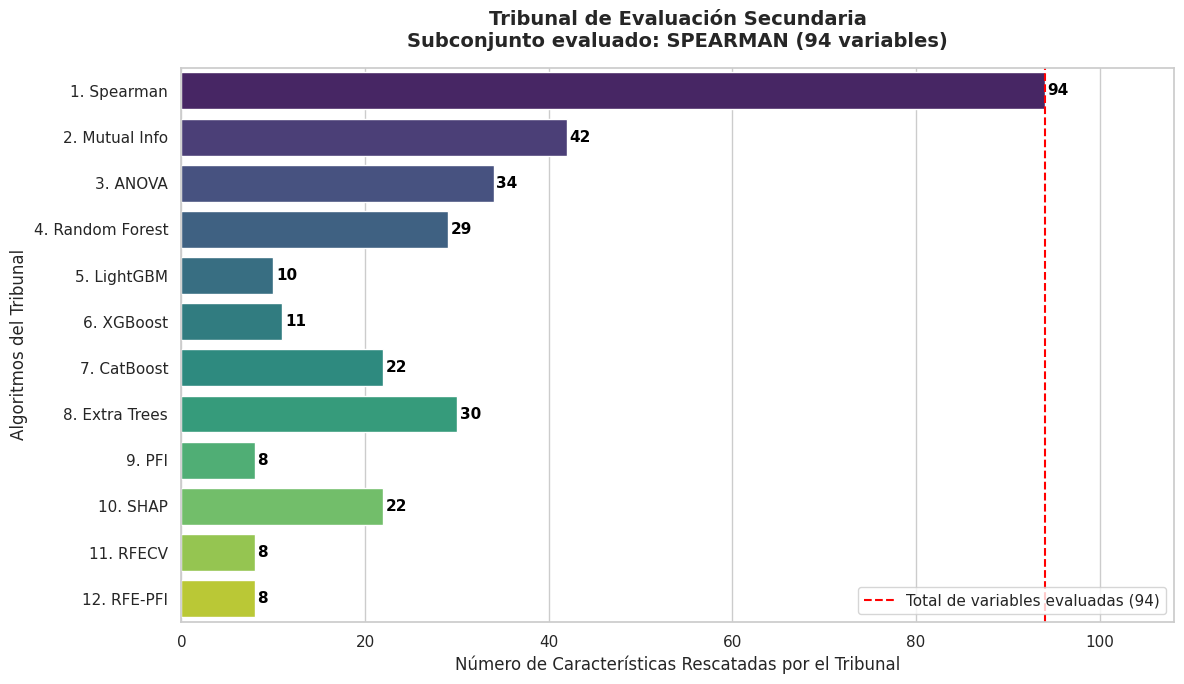

In [ ]:
# [CELDA] FASE 2: EVALUACIÓN SECUNDARIA (EL TRIBUNAL CONSOLIDADO)
import json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif, f_classif, RFECV
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import shap

# =========================================================
# ⚙️ CONFIGURACIÓN: ELIGE A QUÉ ALGORITMO VAS A EVALUAR
# =========================================================
ARCHIVO_BASE = '01_spearman.json'  # < --- CAMBIA ESTO PARA PROBAR OTROS
# =========================================================

print(f"=== FASE 2: TRIBUNAL DE EVALUACIÓN SOBRE '{ARCHIVO_BASE}' ===")
inicio_tribunal = time.time()

# 1. Cargar las características del algoritmo base
try:
    with open(ARCHIVO_BASE, 'r') as f:
        variables_base = json.load(f)
    print(f"✅ Base cargada. El tribunal evaluará un subconjunto de {len(variables_base)} variables.")
except FileNotFoundError:
    print(f"❌ Error: No se encontró el archivo {ARCHIVO_BASE}.")
    variables_base = []

if len(variables_base) > 1:
    # Aislar el dataset SOLO a las variables del algoritmo base
    X_tribunal = X_fast[variables_base]
    X_heavy_tribunal = X_heavy_sample[variables_base]

    resultados_tribunal = []
    diccionario_consolidado = {} # <--- Aquí guardaremos todo para el JSON único

    # Función actualizada: Ahora solo agrupa en memoria
    def registrar_resultado(nombre, conservadas):
        resultados_tribunal.append({'Algoritmo_Evaluador': nombre, 'Variables_Rescatadas': len(conservadas)})
        diccionario_consolidado[nombre] = conservadas # Guardamos la lista en el diccionario
        print(f"   -> {nombre} rescató: {len(conservadas)} variables.")

    # 1. Spearman (Filtro)
    familias = {}
    for col in X_tribunal.columns:
        fam = col.replace('_L5_', '_').replace('_L3_', '_').replace('_L1_', '_').replace('_L0.1_', '_').replace('_L0.01_', '_')
        if fam not in familias: familias[fam] = []
        familias[fam].append(col)
    a_eliminar = []
    for fam, cols in familias.items():
        if len(cols) > 1:
            corr = X_tribunal[cols].corr(method='spearman').abs()
            upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
            for c in upper.columns:
                if any(upper[c] > 0.99): a_eliminar.append(c)
    registrar_resultado('1. Spearman', [c for c in X_tribunal.columns if c not in a_eliminar])

    # 2. Mutual Information
    mi_scores = mutual_info_classif(X_heavy_tribunal, y_heavy_sample, random_state=42)
    registrar_resultado('2. Mutual Info', X_tribunal.columns[mi_scores > np.mean(mi_scores)].tolist())

    # 3. ANOVA
    f_scores, _ = f_classif(X_tribunal.astype('float64'), y_fast)
    registrar_resultado('3. ANOVA', X_tribunal.columns[np.nan_to_num(f_scores, nan=0.0) > np.mean(np.nan_to_num(f_scores, nan=0.0))].tolist())

    # 4. Random Forest
    rf = RandomForestClassifier(n_estimators=40, max_depth=12, random_state=42, n_jobs=-1).fit(X_tribunal, y_fast)
    registrar_resultado('4. Random Forest', X_tribunal.columns[rf.feature_importances_ > np.mean(rf.feature_importances_)].tolist())

    # 5. LightGBM
    lgb_clf = lgb.LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1).fit(X_tribunal, y_fast)
    imp_lgb = lgb_clf.booster_.feature_importance(importance_type='gain')
    registrar_resultado('5. LightGBM', X_tribunal.columns[imp_lgb > np.mean(imp_lgb)].tolist())

    # 6. XGBoost
    xgb_clf = xgb.XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1).fit(X_tribunal, y_fast)
    imp_xgb = np.array([xgb_clf.get_booster().get_score(importance_type='gain').get(c, 0.0) for c in X_tribunal.columns])
    registrar_resultado('6. XGBoost', X_tribunal.columns[imp_xgb > np.mean(imp_xgb)].tolist())

    # 7. CatBoost
    cb_clf = CatBoostClassifier(iterations=100, depth=8, random_state=42, verbose=0, thread_count=-1).fit(X_tribunal, y_fast)
    registrar_resultado('7. CatBoost', X_tribunal.columns[cb_clf.feature_importances_ > np.mean(cb_clf.feature_importances_)].tolist())

    # 8. Extra Trees
    xt = ExtraTreesClassifier(n_estimators=40, max_depth=12, random_state=42, n_jobs=-1).fit(X_tribunal, y_fast)
    registrar_resultado('8. Extra Trees', X_tribunal.columns[xt.feature_importances_ > np.mean(xt.feature_importances_)].tolist())

    # 9. PFI
    dt_base = DecisionTreeClassifier(max_depth=12, random_state=42).fit(X_tribunal, y_fast)
    res_pfi = permutation_importance(dt_base, X_heavy_tribunal, y_heavy_sample, n_repeats=3, random_state=42, n_jobs=-1)
    registrar_resultado('9. PFI', X_tribunal.columns[res_pfi.importances_mean > np.mean(res_pfi.importances_mean)].tolist())

    # 10. SHAP
    rf_shap = RandomForestClassifier(n_estimators=30, max_depth=10, random_state=42, n_jobs=-1).fit(X_heavy_tribunal, y_heavy_sample)
    shap_vals = shap.TreeExplainer(rf_shap).shap_values(X_heavy_tribunal.sample(n=5000, random_state=42))
    imp_shap = np.mean([np.mean(np.abs(sv), axis=0) for sv in shap_vals], axis=0) if isinstance(shap_vals, list) else np.mean(np.abs(shap_vals), axis=(0, 2) if len(shap_vals.shape)==3 else 0)
    registrar_resultado('10. SHAP', X_tribunal.columns[imp_shap > np.mean(imp_shap)].tolist())

    # 11. RFECV
    selector_rfe_puro = RFECV(estimator=DecisionTreeClassifier(max_depth=8, random_state=42), step=2, cv=3, scoring='f1_macro', n_jobs=-1).fit(X_heavy_tribunal, y_heavy_sample)
    rfe_survivors = X_tribunal.columns[selector_rfe_puro.get_support()].tolist()
    registrar_resultado('11. RFECV', rfe_survivors)

    # 12. RFE-PFI
    if len(rfe_survivors) > 0:
        dt_pfi_2 = DecisionTreeClassifier(max_depth=8, random_state=42).fit(X_heavy_tribunal[rfe_survivors], y_heavy_sample)
        res_pfi_2 = permutation_importance(dt_pfi_2, X_heavy_tribunal[rfe_survivors], y_heavy_sample, n_repeats=3, random_state=42, n_jobs=-1)
        registrar_resultado('12. RFE-PFI', np.array(rfe_survivors)[res_pfi_2.importances_mean > 0.001].tolist())
    else:
        registrar_resultado('12. RFE-PFI', [])

    print(f"\n✅ Evaluación del Tribunal finalizada en {round((time.time() - inicio_tribunal)/60, 2)} minutos.")

    # =========================================================
    # 💾 GUARDAR EL JSON CONSOLIDADO (UN SOLO ARCHIVO)
    # =========================================================
    nombre_json_final = f"tribunal_consolidado_{ARCHIVO_BASE}"
    with open(nombre_json_final, 'w') as f:
        json.dump(diccionario_consolidado, f, indent=4) # indent=4 lo hace legible si lo abres
    print(f"💾 ¡Todos los resultados guardados exitosamente en: '{nombre_json_final}'!")

    # =========================================================
    # 📊 VISUALIZACIÓN DE LA FASE 2
    # =========================================================
    df_tribunal = pd.DataFrame(resultados_tribunal)

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 7))

    # Gráfica de barras
    ax = sns.barplot(
        x='Variables_Rescatadas',
        y='Algoritmo_Evaluador',
        data=df_tribunal,
        palette='viridis'
    )

    plt.axvline(x=len(variables_base), color='red', linestyle='--', label=f'Total de variables evaluadas ({len(variables_base)})')

    nombre_base = ARCHIVO_BASE.split('_')[1].split('.')[0].upper() if '_' in ARCHIVO_BASE else ARCHIVO_BASE.split('.')[0].upper()
    plt.title(f'Tribunal de Evaluación Secundaria\nSubconjunto evaluado: {nombre_base} ({len(variables_base)} variables)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Número de Características Rescatadas por el Tribunal', fontsize=12)
    plt.ylabel('Algoritmos del Tribunal', fontsize=12)

    for i, v in enumerate(df_tribunal['Variables_Rescatadas']):
        ax.text(v + 0.3, i, str(v), color='black', va='center', fontweight='bold', fontsize=11)

    plt.xlim(0, len(variables_base) + (len(variables_base) * 0.15))
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

### 🔍 Análisis de Control: Comportamiento Lineal sobre Datos Purificados
Aunque los modelos lineales (Lasso L1, Ridge L2 y ElasticNet) colapsaron a cero durante la evaluación natural sobre el dataset crudo, se realiza una prueba de control secundaria. El objetivo es determinar si dicho colapso fue causado por la naturaleza estrictamente no-lineal del ciberataque, o si fue una consecuencia de la "asfixia matemática" provocada por la multicolinealidad masiva de las 115 características originales. Para ello, se evalúan estos tres algoritmos sobre subconjuntos previamente purificados (ej. SHAP o Spearman).

=== PRUEBA DE CONTROL: MODELOS LINEALES SOBRE '02_mutualinfo.json' ===
✅ Subconjunto cargado: 61 variables purificadas.

Evaluando Lasso L1...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


   -> Lasso L1 rescató: 61 variables.
      💾 ¡Sobrevivieron! Guardadas en 'control_lasso_l1.json'

Evaluando Ridge L2...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


   -> Ridge L2 rescató: 17 variables.
      💾 ¡Sobrevivieron! Guardadas en 'control_ridge_l2.json'

Evaluando ElasticNet...
   -> ElasticNet L1+L2 rescató: 61 variables.
      💾 ¡Sobrevivieron! Guardadas en 'control_elasticnet_l1_l2.json'


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/tmp/ipykernel_11714/171481822.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


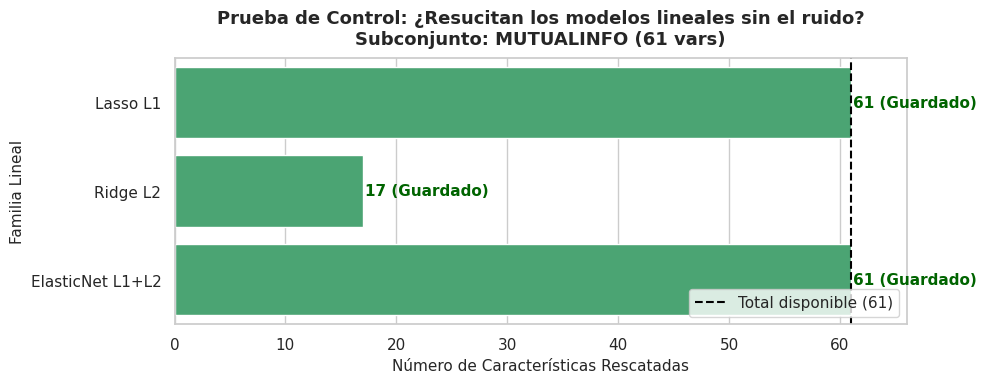

In [ ]:
# [CELDA] FASE 2 (CONTROL): VALIDACIÓN DE LOS MODELOS LINEALES
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

# =========================================================
# ⚙️ CONFIGURACIÓN: ELIGE A QUÉ ALGORITMO VAS A EVALUAR
# =========================================================
ARCHIVO_BASE = '02_mutualinfo.json'  # <--- Prueba con la base limpia de Spearman
# =========================================================

print(f"=== PRUEBA DE CONTROL: MODELOS LINEALES SOBRE '{ARCHIVO_BASE}' ===")

try:
    with open(ARCHIVO_BASE, 'r') as f:
        variables_base = json.load(f)
    print(f"✅ Subconjunto cargado: {len(variables_base)} variables purificadas.")
except FileNotFoundError:
    print(f"❌ Error: No se encontró el archivo {ARCHIVO_BASE}.")
    variables_base = []

if len(variables_base) > 0:
    X_control = X_fast[variables_base]
    resultados_lineales = []

    def evaluar_lineal(nombre, modelo, usar_media=False):
        modelo.fit(X_control, y_fast)
        pesos = np.sum(np.abs(modelo.coef_), axis=0)

        # Ridge a veces necesita evaluarse por la media porque no empuja todo a cero absoluto como L1
        umbral = np.mean(pesos) if usar_media else 0.001
        conservadas = X_control.columns[pesos > umbral].tolist()

        resultados_lineales.append({'Modelo Lineal': nombre, 'Variables_Rescatadas': len(conservadas)})
        print(f"   -> {nombre} rescató: {len(conservadas)} variables.")

        # Novedad: Guardar en JSON SÓLO si rescató algo
        if len(conservadas) > 0:
            nombre_archivo = f"control_{nombre.replace(' ', '_').replace('+', '_').lower()}.json"
            with open(nombre_archivo, 'w') as f:
                json.dump(conservadas, f)
            print(f"      💾 ¡Sobrevivieron! Guardadas en '{nombre_archivo}'")

    # 1. Lasso L1
    print("\nEvaluando Lasso L1...")
    lasso = LogisticRegression(penalty='l1', solver='saga', C=1.0, max_iter=150, random_state=42, n_jobs=-1)
    evaluar_lineal('Lasso L1', lasso, usar_media=False)

    # 2. Regresión Ridge L2
    print("\nEvaluando Ridge L2...")
    ridge = LogisticRegression(penalty='l2', solver='saga', max_iter=150, random_state=42, n_jobs=-1)
    evaluar_lineal('Ridge L2', ridge, usar_media=True)

    # 3. ElasticNet
    print("\nEvaluando ElasticNet...")
    elastic = LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, C=1.0, max_iter=150, random_state=42, n_jobs=-1)
    evaluar_lineal('ElasticNet L1+L2', elastic, usar_media=False)

    # =========================================================
    # 📊 VISUALIZACIÓN DE LA PRUEBA DE CONTROL
    # =========================================================
    df_lineales = pd.DataFrame(resultados_lineales)

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 4))

    # Colores dinámicos: Rojo si es 0, Verde si rescató algo
    colores = ['#B22222' if v == 0 else '#3CB371' for v in df_lineales['Variables_Rescatadas']]

    ax = sns.barplot(
        x='Variables_Rescatadas',
        y='Modelo Lineal',
        data=df_lineales,
        palette=colores
    )

    plt.axvline(x=len(variables_base), color='black', linestyle='--', label=f'Total disponible ({len(variables_base)})')

    nombre_base = ARCHIVO_BASE.split('_')[1].split('.')[0].upper() if '_' in ARCHIVO_BASE else ARCHIVO_BASE
    plt.title(f'Prueba de Control: ¿Resucitan los modelos lineales sin el ruido?\nSubconjunto: {nombre_base} ({len(variables_base)} vars)', fontsize=13, fontweight='bold', pad=10)
    plt.xlabel('Número de Características Rescatadas', fontsize=11)
    plt.ylabel('Familia Lineal', fontsize=11)

    for i, v in enumerate(df_lineales['Variables_Rescatadas']):
        texto = f"{v} (Guardado)" if v > 0 else "0 (Colapso Total)"
        color_texto = 'darkgreen' if v > 0 else 'darkred'
        ax.text(v + 0.2, i, texto, color=color_texto, va='center', fontweight='bold', fontsize=11)

    plt.xlim(0, max(len(variables_base) + 5, 10))
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

=== GENERANDO MATRIZ DE SUPERVIVENCIA (CONSOLIDADO) ===


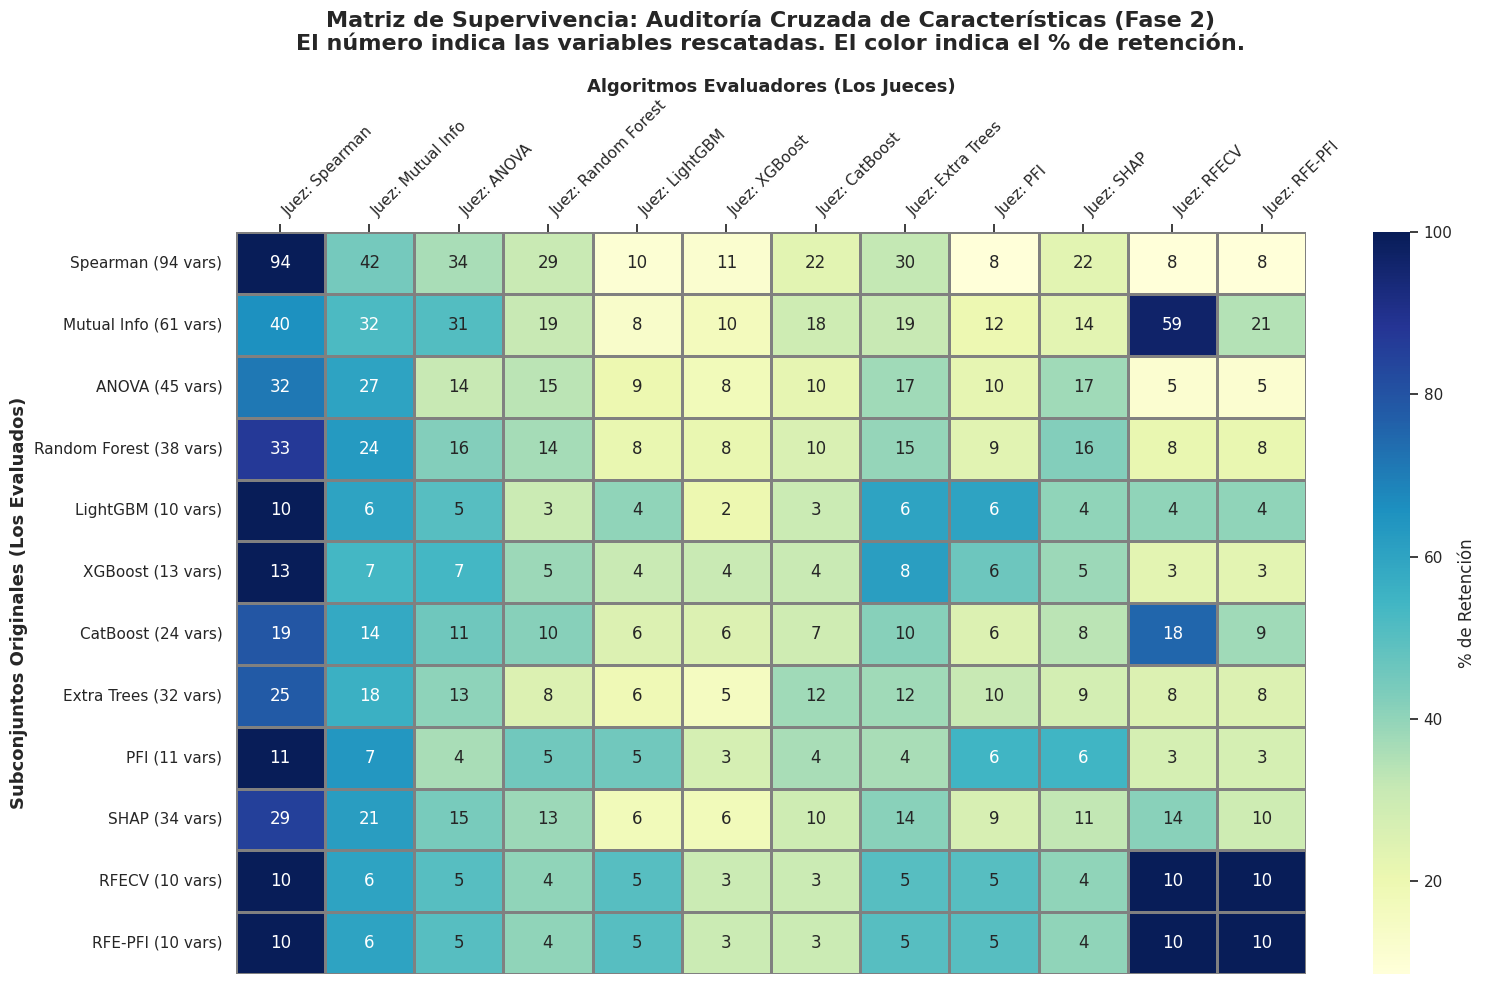

In [ ]:
# [CELDA] GRÁFICA MAESTRA CONSOLIDADA: MATRIZ DE SUPERVIVENCIA (TRIBUNAL FASE 2)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("=== GENERANDO MATRIZ DE SUPERVIVENCIA (CONSOLIDADO) ===")

# Datos exactos extraídos de tus pruebas en consola
# Filas: Algoritmo Base (El evaluado)
# Columnas: Algoritmo del Tribunal (El juez)
# Valores: Porcentaje de retención (Variables Rescatadas / Variables Base)

bases = [
    'Spearman (94 vars)', 'Mutual Info (61 vars)', 'ANOVA (45 vars)',
    'Random Forest (38 vars)', 'LightGBM (10 vars)', 'XGBoost (13 vars)',
    'CatBoost (24 vars)', 'Extra Trees (32 vars)', 'PFI (11 vars)',
    'SHAP (34 vars)', 'RFECV (10 vars)', 'RFE-PFI (10 vars)'
]

jueces = [
    'Juez: Spearman', 'Juez: Mutual Info', 'Juez: ANOVA', 'Juez: Random Forest',
    'Juez: LightGBM', 'Juez: XGBoost', 'Juez: CatBoost', 'Juez: Extra Trees',
    'Juez: PFI', 'Juez: SHAP', 'Juez: RFECV', 'Juez: RFE-PFI'
]

# Matriz de variables rescatadas en crudo
valores_crudos = [
    [94, 42, 34, 29, 10, 11, 22, 30, 8, 22, 8, 8],      # Base Spearman
    [40, 32, 31, 19, 8, 10, 18, 19, 12, 14, 59, 21],    # Base Mutual Info
    [32, 27, 14, 15, 9, 8, 10, 17, 10, 17, 5, 5],       # Base ANOVA
    [33, 24, 16, 14, 8, 8, 10, 15, 9, 16, 8, 8],        # Base Random Forest
    [10, 6, 5, 3, 4, 2, 3, 6, 6, 4, 4, 4],              # Base LightGBM
    [13, 7, 7, 5, 4, 4, 4, 8, 6, 5, 3, 3],              # Base XGBoost
    [19, 14, 11, 10, 6, 6, 7, 10, 6, 8, 18, 9],         # Base CatBoost
    [25, 18, 13, 8, 6, 5, 12, 12, 10, 9, 8, 8],         # Base Extra Trees
    [11, 7, 4, 5, 5, 3, 4, 4, 6, 6, 3, 3],              # Base PFI
    [29, 21, 15, 13, 6, 6, 10, 14, 9, 11, 14, 10],      # Base SHAP
    [10, 6, 5, 4, 5, 3, 3, 5, 5, 4, 10, 10],            # Base RFECV
    [10, 6, 5, 4, 5, 3, 3, 5, 5, 4, 10, 10]             # Base RFE-PFI
]

# Totales originales de cada base para calcular el porcentaje
totales_base = [94, 61, 45, 38, 10, 13, 24, 32, 11, 34, 10, 10]

# Calcular matriz de porcentajes
matriz_porcentajes = []
for i in range(len(valores_crudos)):
    fila_porcentajes = [(val / totales_base[i]) * 100 for val in valores_crudos[i]]
    matriz_porcentajes.append(fila_porcentajes)

df_heatmap = pd.DataFrame(matriz_porcentajes, index=bases, columns=jueces)

# Configuración Visual del Heatmap
plt.figure(figsize=(16, 10))
sns.set_theme(style="white")

# Usamos un mapa de colores donde azul oscuro es 100% de retención y claro es 0%
ax = sns.heatmap(df_heatmap, annot=np.array(valores_crudos), fmt="d", cmap="YlGnBu",
                 linewidths=1, linecolor='gray', cbar_kws={'label': '% de Retención'})

plt.title('Matriz de Supervivencia: Auditoría Cruzada de Características (Fase 2)\nEl número indica las variables rescatadas. El color indica el % de retención.',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Algoritmos Evaluadores (Los Jueces)', fontsize=13, fontweight='bold')
plt.ylabel('Subconjuntos Originales (Los Evaluados)', fontsize=13, fontweight='bold')

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
plt.xticks(rotation=45, ha='left', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

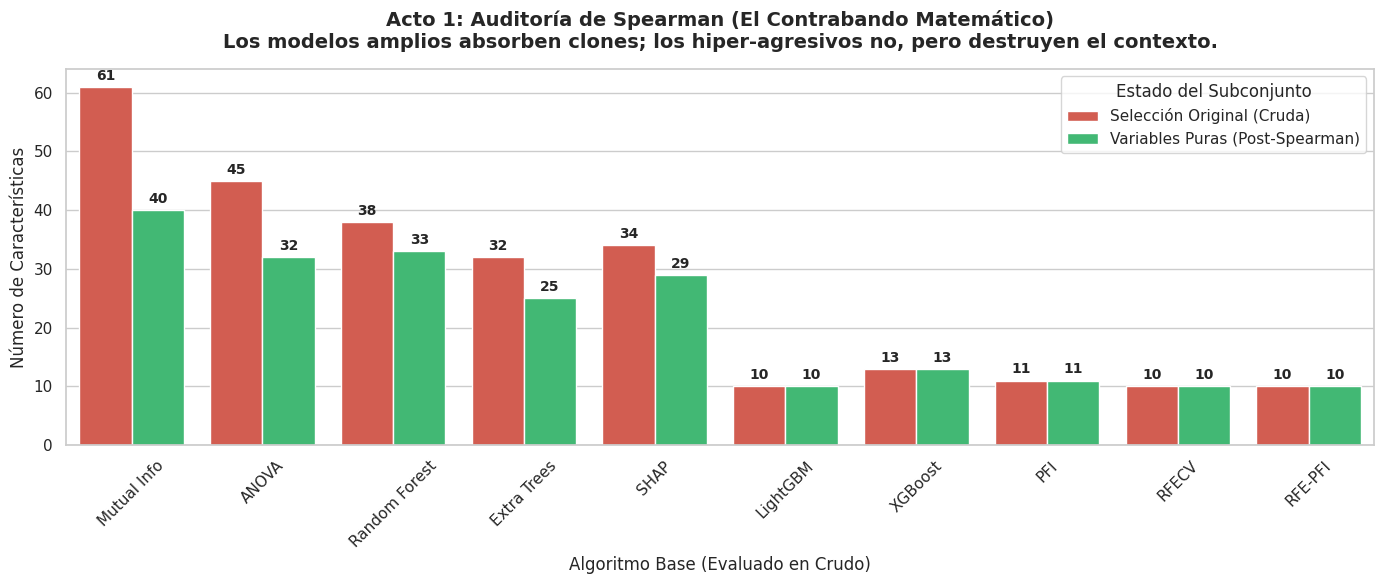

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Acto 1 Actualizado: Todos los algoritmos
datos_contrabando = {
    'Algoritmo Evaluado': ['Mutual Info', 'ANOVA', 'Random Forest', 'Extra Trees', 'SHAP', 'LightGBM', 'XGBoost', 'PFI', 'RFECV', 'RFE-PFI'],
    'Selección Original (Cruda)': [61, 45, 38, 32, 34, 10, 13, 11, 10, 10],
    'Variables Puras (Post-Spearman)': [40, 32, 33, 25, 29, 10, 13, 11, 10, 10] # Los destructores quedan intactos
}

df_contra = pd.DataFrame(datos_contrabando)
df_melted = df_contra.melt(id_vars='Algoritmo Evaluado', var_name='Estado', value_name='Cantidad')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    x='Algoritmo Evaluado', y='Cantidad', hue='Estado', data=df_melted,
    palette=['#e74c3c', '#2ecc71']
)

plt.title('Acto 1: Auditoría de Spearman (El Contrabando Matemático)\nLos modelos amplios absorben clones; los hiper-agresivos no, pero destruyen el contexto.', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Número de Características', fontsize=12)
plt.xlabel('Algoritmo Base (Evaluado en Crudo)', fontsize=12)
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontweight='bold', fontsize=10)

plt.legend(title='Estado del Subconjunto')
plt.tight_layout()
plt.show()

/tmp/ipykernel_11714/884361396.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


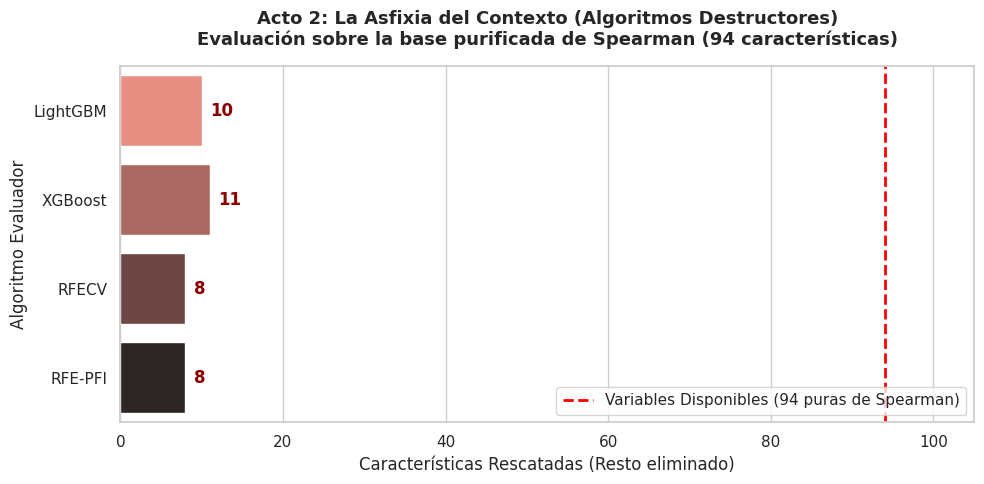

In [ ]:
# [CELDA] ACTO 2: EL PELIGRO DE LOS DESTRUCTORES
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Datos cuando los "Destructores" evaluaron la base purificada de Spearman (94 vars)
datos_destructores = {
    'Algoritmo Juez (El Destructor)': ['LightGBM', 'XGBoost', 'RFECV', 'RFE-PFI'],
    'Variables Rescatadas': [10, 11, 8, 8]
}

df_dest = pd.DataFrame(datos_destructores)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# Gráfica de barras
ax = sns.barplot(
    x='Variables Rescatadas',
    y='Algoritmo Juez (El Destructor)',
    data=df_dest,
    palette='dark:salmon_r'
)

# La línea roja que muestra lo que tenían disponible
plt.axvline(x=94, color='red', linestyle='--', linewidth=2, label='Variables Disponibles (94 puras de Spearman)')

plt.title('Acto 2: La Asfixia del Contexto (Algoritmos Destructores)\nEvaluación sobre la base purificada de Spearman (94 características)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Características Rescatadas (Resto eliminado)', fontsize=12)
plt.ylabel('Algoritmo Evaluador', fontsize=12)

for i, v in enumerate(df_dest['Variables Rescatadas']):
    ax.text(v + 1, i, str(v), color='darkred', va='center', fontweight='bold', fontsize=12)

plt.xlim(0, 105)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
import json

# Nombre de tu archivo consolidado donde Spearman era la base (94 variables)
ARCHIVO_MAESTRO = 'tribunal_consolidado_01_spearman.json'

print("=== EXTRACCIÓN DEL VECTOR DE CARACTERÍSTICAS FINAL ===")

try:
    with open(ARCHIVO_MAESTRO, 'r') as f:
        datos_tribunal = json.load(f)

    # Extraemos las selecciones de nuestros dos "Jueces Supremos"
    juez_shap = set(datos_tribunal.get('10. SHAP', []))
    juez_rfepfi = set(datos_tribunal.get('12. RFE-PFI', []))

    print(f"✔️ SHAP rescató: {len(juez_shap)} variables.")
    print(f"✔️ RFE-PFI rescató: {len(juez_rfepfi)} variables.")

    # Consenso Estricto (Intersección: Solo si AMBOS están de acuerdo)
    consenso_estricto = list(juez_shap.intersection(juez_rfepfi))

    # Consenso Amplio (Unión: Si al menos UNO de los dos dice que es importante)
    consenso_amplio = list(juez_shap.union(juez_rfepfi))

    print("\n--- RESULTADOS DEL CONSENSO ---")
    print(f"🧬 Vector Estricto (Intersección): {len(consenso_estricto)} características.")
    print(f"🧬 Vector Amplio (Unión): {len(consenso_amplio)} características.")

    # Guardar los vectores finales para usarlos en el entrenamiento de BERT-Mini
    with open('vector_final_estricto.json', 'w') as f:
        json.dump(consenso_estricto, f, indent=4)
    with open('vector_final_amplio.json', 'w') as f:
        json.dump(consenso_amplio, f, indent=4)

    print("\n💾 Vectores guardados como 'vector_final_estricto.json' y 'vector_final_amplio.json'")

    print("\nTop 5 Variables del Vector Amplio (vistazo rápido):")
    for var in consenso_amplio[:5]:
        print(f" - {var}")

except FileNotFoundError:
    print(f"❌ Error: Asegúrate de que el archivo '{ARCHIVO_MAESTRO}' esté en la carpeta actual.")

=== EXTRACCIÓN DEL VECTOR DE CARACTERÍSTICAS FINAL ===
✔️ SHAP rescató: 22 variables.
✔️ RFE-PFI rescató: 8 variables.

--- RESULTADOS DEL CONSENSO ---
🧬 Vector Estricto (Intersección): 4 características.
🧬 Vector Amplio (Unión): 26 características.

💾 Vectores guardados como 'vector_final_estricto.json' y 'vector_final_amplio.json'

Top 5 Variables del Vector Amplio (vistazo rápido):
 - H_L5_weight
 - MI_dir_L0.01_mean
 - MI_dir_L0.1_mean
 - HpHp_L0.1_radius
 - HH_jit_L0.1_variance


In [6]:
# [CELDA] EXTRACCIÓN DE VECTORES POR VOTACIÓN MAYORITARIA
import json
from collections import Counter

# Nombre de tu archivo consolidado base
ARCHIVO_MAESTRO = 'tribunal_consolidado_01_spearman.json'

print("=== EXTRACCIÓN POR CONSENSO GLOBAL (VOTACIÓN MAYORITARIA) ===")

try:
    with open(ARCHIVO_MAESTRO, 'r') as f:
        datos_tribunal = json.load(f)

    todas_las_caracteristicas = []
    num_jueces = len(datos_tribunal)

    # 1. Recolectar todas las variables sugeridas por todos los jueces
    for juez, variables in datos_tribunal.items():
        todas_las_caracteristicas.extend(variables)

    # 2. Contar cuántos votos tiene cada característica
    conteo_votos = Counter(todas_las_caracteristicas)

    print(f"👨‍⚖️ Total de algoritmos (jueces) que votaron: {num_jueces}\n")

    # 3. Definir umbrales de votación
    consenso_absoluto = [var for var, votos in conteo_votos.items() if votos == num_jueces]
    consenso_alto = [var for var, votos in conteo_votos.items() if votos >= 10]
    consenso_medio = [var for var, votos in conteo_votos.items() if votos >= 7]
    consenso_bajo = [var for var, votos in conteo_votos.items() if votos >= 4]
    consenso_minimo = [var for var, votos in conteo_votos.items() if votos >= 2]

    print("--- RESULTADOS DE LA VOTACIÓN ---")
    print(f"🏆 Unanimidad (Votaron 12 de 12): {len(consenso_absoluto)} características.")
    print(f"🥇 Consenso Alto (>= 10 votos): {len(consenso_alto)} características.")
    print(f"🥈 Mayoría Simple (>= 7 votos): {len(consenso_medio)} características.\n")
    print(f"🥈 Mayoría Simple (>= 4 votos): {len(consenso_bajo)} características.\n")
    print(f"🥈 Mayoría Simple (>= 2 votos): {len(consenso_minimo)} características.\n")

    # 4. Mostrar el Top 10 de características más votadas
    print("🌟 El TOP 10 Absoluto del ADN del Ataque:")
    for var, votos in conteo_votos.most_common(10):
        print(f"   [{votos}/{num_jueces} votos] -> {var}")

    # 5. Guardar los nuevos vectores
    with open('vector_consenso_alto_10.json', 'w') as f:
        json.dump(consenso_alto, f, indent=4)
    with open('vector_mayoria_simple_7.json', 'w') as f:
        json.dump(consenso_medio, f, indent=4)

    print("\n💾 Vectores guardados como 'vector_consenso_alto_10.json' y 'vector_mayoria_simple_7.json'")

except FileNotFoundError:
    print(f"❌ Error: Asegúrate de que el archivo '{ARCHIVO_MAESTRO}' esté en la carpeta actual.")

=== EXTRACCIÓN POR CONSENSO GLOBAL (VOTACIÓN MAYORITARIA) ===
👨‍⚖️ Total de algoritmos (jueces) que votaron: 12

--- RESULTADOS DE LA VOTACIÓN ---
🏆 Unanimidad (Votaron 12 de 12): 1 características.
🥇 Consenso Alto (>= 10 votos): 3 características.
🥈 Mayoría Simple (>= 7 votos): 14 características.

🥈 Mayoría Simple (>= 4 votos): 39 características.

🥈 Mayoría Simple (>= 2 votos): 57 características.

🌟 El TOP 10 Absoluto del ADN del Ataque:
   [12/12 votos] -> HH_jit_L0.01_mean
   [11/12 votos] -> H_L0.1_weight
   [10/12 votos] -> H_L0.01_mean
   [9/12 votos] -> MI_dir_L0.1_weight
   [9/12 votos] -> HH_L0.1_covariance
   [9/12 votos] -> HH_jit_L5_mean
   [9/12 votos] -> HH_jit_L0.1_mean
   [8/12 votos] -> MI_dir_L0.01_mean
   [8/12 votos] -> H_L0.01_weight
   [7/12 votos] -> MI_dir_L0.1_mean

💾 Vectores guardados como 'vector_consenso_alto_10.json' y 'vector_mayoria_simple_7.json'


=== LA PRUEBA DE FUEGO: RENDIMIENTO VS LATENCIA EN EL EDGE ===
✅ Vector Consenso cargado: 14 características.
📦 Set de Prueba: 20000 paquetes de red para inferir.

▶️ Modelo Base Crudo (115 Vars):
   - F1-Score: 0.9997 | Precisión: 0.9997
   - Latencia de Inferencia (20000 datos): 69.12 ms
▶️ Modelo Optimizado Edge (14 Vars):
   - F1-Score: 0.9997 | Precisión: 0.9997
   - Latencia de Inferencia (20000 datos): 37.10 ms


/tmp/ipykernel_11714/2084386614.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x='Modelo', y='F1-Score', data=df_res, palette=['#e74c3c', '#2ecc71'], ax=axes[0])
/tmp/ipykernel_11714/2084386614.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x='Modelo', y='Latencia (ms)', data=df_res, palette=['#c0392b', '#27ae60'], ax=axes[1])


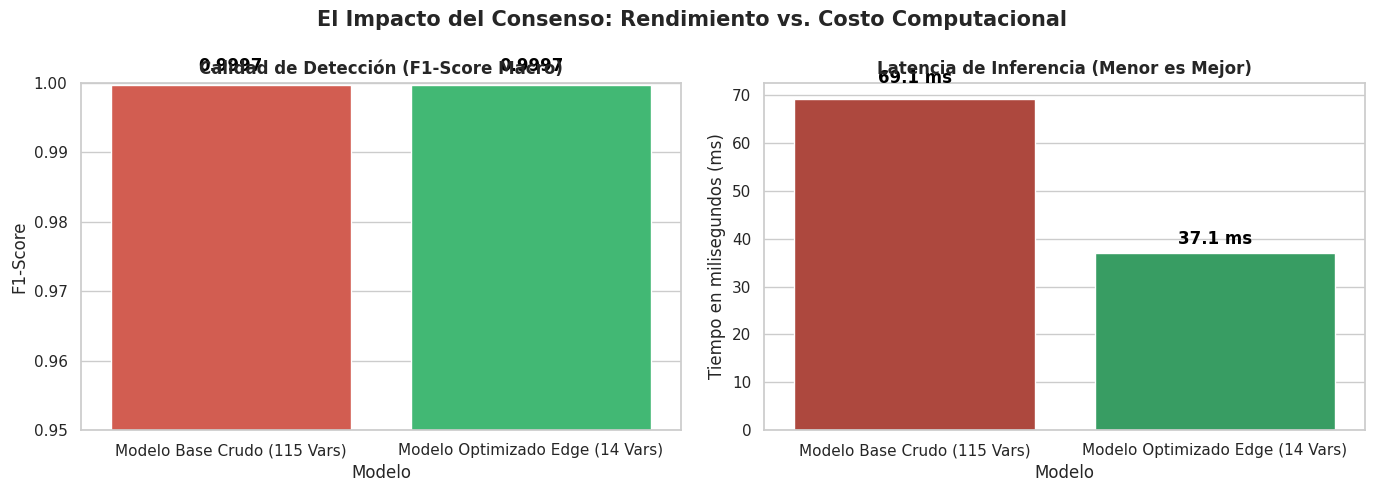

In [ ]:
# [CELDA] LA PRUEBA DE FUEGO: 115 VARIABLES VS 14 VARIABLES (CONSENSO)
import json, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import train_test_split

print("=== LA PRUEBA DE FUEGO: RENDIMIENTO VS LATENCIA EN EL EDGE ===")

# 1. Cargar el Vector Ganador (14 características)
try:
    with open('vector_mayoria_simple_7.json', 'r') as f:
        vector_14 = json.load(f)
    print(f"✅ Vector Consenso cargado: {len(vector_14)} características.")
except FileNotFoundError:
    print("❌ Error: No se encontró 'vector_mayoria_simple_7.json'.")
    vector_14 = []

if len(vector_14) > 0:
    # 2. Preparar un dataset de prueba estricto (Hold-out Test)
    # Usamos 80% para entrenar y 20% para medir latencia real de predicción
    X_train_full, X_test_full, y_train, y_test = train_test_split(
        X_fast, y_fast, test_size=0.2, random_state=42, stratify=y_fast
    )

    # Dataset reducido
    X_train_red = X_train_full[vector_14]
    X_test_red = X_test_full[vector_14]

    print(f"📦 Set de Prueba: {X_test_full.shape[0]} paquetes de red para inferir.\n")

    # 3. Función de Evaluación
    def evaluar_modelo(nombre, X_tr, X_te, y_tr, y_te):
        modelo = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)

        # Medir tiempo de entrenamiento
        t_ini_train = time.time()
        modelo.fit(X_tr, y_tr)
        t_train = time.time() - t_ini_train

        # Medir tiempo de inferencia (Latencia) simulando el Edge
        t_ini_pred = time.time()
        preds = modelo.predict(X_te)
        t_pred = (time.time() - t_ini_pred) * 1000 # Convertir a milisegundos

        f1 = f1_score(y_te, preds, average='macro')
        acc = accuracy_score(y_te, preds)

        print(f"▶️ {nombre}:")
        print(f"   - F1-Score: {f1:.4f} | Precisión: {acc:.4f}")
        print(f"   - Latencia de Inferencia ({X_te.shape[0]} datos): {t_pred:.2f} ms")

        return {'Modelo': nombre, 'F1-Score': f1, 'Latencia (ms)': t_pred, 'Variables': X_tr.shape[1]}

    # 4. Batalla
    res_goliat = evaluar_modelo("Modelo Base Crudo (115 Vars)", X_train_full, X_test_full, y_train, y_test)
    res_david = evaluar_modelo("Modelo Optimizado Edge (14 Vars)", X_train_red, X_test_red, y_train, y_test)

    # 5. Dashboard Comparativo
    df_res = pd.DataFrame([res_goliat, res_david])

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('El Impacto del Consenso: Rendimiento vs. Costo Computacional', fontsize=15, fontweight='bold')

    # Gráfica 1: F1-Score (Precisión)
    ax1 = sns.barplot(x='Modelo', y='F1-Score', data=df_res, palette=['#e74c3c', '#2ecc71'], ax=axes[0])
    axes[0].set_title('Calidad de Detección (F1-Score Macro)', fontweight='bold')
    axes[0].set_ylim(0.95, 1.0) # Zoom arriba porque ambos serán muy buenos
    for i, v in enumerate(df_res['F1-Score']):
        ax1.text(i, v + 0.002, f"{v:.4f}", color='black', ha='center', fontweight='bold', fontsize=12)

    # Gráfica 2: Latencia
    ax2 = sns.barplot(x='Modelo', y='Latencia (ms)', data=df_res, palette=['#c0392b', '#27ae60'], ax=axes[1])
    axes[1].set_title('Latencia de Inferencia (Menor es Mejor)', fontweight='bold')
    axes[1].set_ylabel('Tiempo en milisegundos (ms)')
    for i, v in enumerate(df_res['Latencia (ms)']):
        ax2.text(i, v + (v*0.05), f"{v:.1f} ms", color='black', ha='center', fontweight='bold', fontsize=12)

    plt.tight_layout()
    plt.show()